<a href="https://colab.research.google.com/github/glafica/TP_Final_Data_Analytics/blob/main/TPFinal_GL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><font color="yellow">📊 ENTREGA PROYECTO FINAL TRABAJO INTEGRADOR 📊</font></h1>

* Curso: Data Analytics
* Comisión: **25261**
* Alumno: **G.L.**
* Fecha: 30/11/2025

Este trabajo Final se basa en el código realizado para la Pre-Entrega en su etapas:

Etapa 1: Recopilación y Preparación de Datos (Clase 1 a 4)

Etapa 2: Preprocesamiento y Limpieza de Datos (Clase 5 a 8)

___________________________________________________________________________

Limpieza e integración de datos

1: Cargar Data Sets: ventas.csv y marketing.csv.

2: Agregar ventas por producto, ventas_total (suma de importe) y
unidades_vendidas (suma de cantidad).

3: Agregar marketing por producto inversion_total (suma costo).

4: Merge por producto (outer) para no preder productos que aparezcan en solo una fuente.

5: Derivar indicadores: ticket_medio (= ventas_total/unidades_vendidas) y Roas (=ventas_total/inversion_total).

6: Ordenar y esportar el resultado.


#👉 ***ETAPA 1 - Recopilación y Preparación de Datos:***

* Crear un documento en Google Colaboratory y cargar los sets de datos como DataFrames.

In [8]:
# IMPORTO LAS LIBRERIAS:
import pandas as pd
import numpy as np
import unicodedata

# IMPORTO LOS ARCHIVOS DESDE GITHUB:
url_clientes = 'https://raw.githubusercontent.com/glafica/TP_Final_Data_Analytics/refs/heads/main/clientes.csv'
url_productos = 'https://raw.githubusercontent.com/glafica/TP_Final_Data_Analytics/refs/heads/main/marketing.csv'
url_ventas = 'https://raw.githubusercontent.com/glafica/TP_Final_Data_Analytics/refs/heads/main/ventas.csv'

# Verificamos que cargó bien
print("Datos cargados con éxito")
clientes.head()

# HAGO UNA EXPLORACION RAPIDA DE LOS 3 ARCHIVOS (Filas y Columnas):
print("─"*150)
print("EXPLORACION DE LOS TRES DATAFRAMES")
print()
print("ventas:", ventas.shape)
print("clientes:", clientes.shape)
print("marketing:", marketing.shape)
print("─"*150)

Datos cargados con éxito
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
EXPLORACION DE LOS TRES DATAFRAMES

ventas: (3035, 6)
clientes: (567, 5)
marketing: (90, 6)
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


# 👉***ETAPA 2 - Preprocesamiento y Limpieza de Datos***

* Introducción a Pandas: realizar un análisis exploratorio inicial de los DataFrames.
* Calidad de Datos: Identificar valores nulos y duplicados en los conjuntos de datos. Documentar el estado inicial de los datos.



In [9]:
# NORMALIZO EL CAMPO PRECIO. LO PASO DE STRING A FLOAT:

if "precio" in ventas.columns:
    ventas["precio"] = (ventas["precio"]
                        .astype(str)
                        .str.replace(r"[$,\s]", "", regex=True)
                        .replace({"nan": np.nan}))
    ventas["precio"] = pd.to_numeric(ventas["precio"], errors="coerce")

# PARSEO LAS FECHAS EN LOS DATAFRAMES VENTAS Y MARKETING:

if "fecha_venta" in ventas.columns:
  ventas["fecha_venta"] = pd.to_datetime(ventas["fecha_venta"], dayfirst=True, errors="coerce")

for col in ["fecha_inicio","fecha_fin"]:
    if col in marketing.columns:
       marketing[col] = pd.to_datetime(marketing[col], dayfirst=True, errors="coerce")

# ELIMINO LOS DUPLICADOS:

len_antes = len(ventas)
ventas = ventas.drop_duplicates().copy()
len_despues = len(ventas)
dup_eliminados = len_antes - len_despues

# CREO LA COLUMNA IMPORTE EN EL DATAFRAME VENTAS:
ventas["importe"] = ventas ["precio"] * ventas ["cantidad"]

# COMPRUEBO QUE SE HAYAN CREADO LAS COLUMNAS EN AMBOS DATAFRAMES:
print("─"*150)
print("COMPRUEBO COLUMNAS")
print()
display(ventas.head(2))
print("─"*150)
display(marketing.head(2))
print("─"*150)


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
COMPRUEBO COLUMNAS



,id_venta,producto,precio,cantidad,fecha_venta,categoria,importe
0,792,Cuadro decorativo,69.94,5.0,2024-01-02,Decoración,349.7
1,811,Lámpara de mesa,105.10,5.0,2024-01-02,Decoración,525.5


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03
1,12,Tablet,RRSS,3.40,2024-03-26,2024-05-13


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


##### COMBINACION DE AMBOS DATAFRAMES POR ID PRODUCTO


* Agrupación por producto en "ventas".
* Agrupación por producto en "marketing".
* Merge de las anteriores por producto en un nuevo dataframe llamado "prod_global"

In [10]:
# AGRUPACION EN VENTAS:

ventas_prod = (ventas
            .groupby("producto", as_index=False)
            .agg(ventas_total=("importe", "sum"),
                 unidades_vendidas=("cantidad", "sum")))
ventas_prod = ventas_prod.sort_values("ventas_total", ascending=False, ignore_index=True)


# AGRUPACION EN MARKETING:

mkt_prod = (marketing
            .groupby("producto", as_index=False)
            .agg(inversion_total=("costo", "sum"),
                 campañas=("id_campanha", "count")))
mkt_prod = mkt_prod.sort_values("inversion_total", ascending=False, ignore_index=True)

# CORROBORO MOSTRANDO LA AGRUPACION EN AMBOS DATAFRAMES:
print("─"*150)
print("ENCABEZADOS: VENTAS")
display(ventas_prod.head())
print("─"*150)
print()
print("─"*150)
print("ENCABEZADOS: MARKETING")
display(mkt_prod.head())
print("─"*150)

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
ENCABEZADOS: VENTAS


,producto,ventas_total,unidades_vendidas
0,Lámpara de mesa,82276.38,1112.0
1,Auriculares,74175.58,958.0
2,Microondas,72562.89,912.0
3,Cafetera,59607.31,765.0
4,Cuadro decorativo,54297.60,726.0


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
ENCABEZADOS: MARKETING


,producto,inversion_total,campañas
0,Cafetera,18.16,3
1,Alfombra,17.46,3
2,Cortinas,17.36,3
3,Elementos de cerámica,16.87,3
4,Aspiradora,16.46,3


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [11]:
# HAGO EL MERGE DE LOS DOS DATAFRAMES ANTERIORES POR ID PRODUCTO

prod_global = (ventas_prod
               .merge(mkt_prod, on="producto", how="outer"))

# CAMBIO NaN POR CEROS SI LOS HUBIERA PARA QUE NO GENERE ERROR POSTERIOR.
for col in ["ventas_total", "unidades_vendidas", "inversion_total", "campañas"]:
    if col in prod_global.columns:
        prod_global[col] = prod_global[col].fillna(0)
print("─"*150)
print('ENCABEZADOS: "PROD_GLOBAL"')
display(prod_global.head())
print("─"*150)

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
ENCABEZADOS: "PROD_GLOBAL"


,producto,ventas_total,unidades_vendidas,inversion_total,campañas
0,Adorno de pared,48093.49,633.0,14.05,3
1,Alfombra,44773.06,615.0,17.46,3
2,Aspiradora,50085.86,651.0,16.46,3
3,Auriculares,74175.58,958.0,15.24,3
4,Batidora,50979.20,672.0,15.28,3


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


##### CREANDO COLUMNAS CON KPI"s PARA INTEGRAR AL ANALISIS POSTERIOR


* Tiket Medio: "ventas_total" / "unidades_vendidas" (no dividir por cero).
* (*) ROAS: "ventas_total" / "inversion_total" (si no hay inversión dejo cero).
* Ordenamiento de la tabla por "ventas_total" (mayor a menor).

(*)*El ROAS o retorno de la inversión publicitaria, es una métrica de marketing que mide la efectividad de una campaña publicitaria al calcular los ingresos que genera por cada dólar o euro gastado. Para calcularlo, se divide el ingreso total de la campaña entre el costo de la campaña publicitaria. Es útil para determinar si una campaña publicitaria es rentable y para optimizar estrategias futuras.*

In [12]:
# CREO KPI TICKET MEDIO = ventas_total/unidades_vendidas:

prod_global["ticket_medio"] = prod_global.apply(
    lambda r: (r["ventas_total"] / r["unidades_vendidas"]) if r["unidades_vendidas"] else 0, # pongo cero si no hay unidades vendidas
    axis=1
).round(2)

# CREO KPI ROAS = ventas_total/inversion_total:

prod_global["ROAS"] = prod_global.apply(
    lambda r: (r["ventas_total"] / r["inversion_total"]) if r["inversion_total"] else 0, # pongo cero si no hay inversion total
    axis=1
).round(2)

# ORDENO POR ventas_total DE MAYOR A MENOR:

prod_global = prod_global.sort_values(["ventas_total", "inversion_total"], ascending=[False, False], ignore_index=True)

print("─"*150)
print("10 ULTIMAS FILAS DE: PROD_GLOBAL")
display(prod_global.tail(10))
print("─"*150)


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
10 ULTIMAS FILAS DE: PROD_GLOBAL


,producto,ventas_total,unidades_vendidas,inversion_total,campañas,ticket_medio,ROAS
20,Laptop,46179.48,617.0,15.19,3,74.85,3040.12
21,Consola de videojuegos,46174.41,623.0,12.77,3,74.12,3615.85
22,Elementos de cerámica,45411.09,636.0,16.87,3,71.40,2691.83
23,Cámara digital,45217.96,638.0,16.40,3,70.87,2757.19
24,Plancha de vapor,45196.63,632.0,14.12,3,71.51,3200.89
25,Cortinas,44865.03,610.0,17.36,3,73.55,2584.39
26,Alfombra,44773.06,615.0,17.46,3,72.80,2564.32
27,Tablet,25856.57,374.0,12.72,3,69.14,2032.75
28,Heladera,25736.80,330.0,13.11,3,77.99,1963.14
29,Candelabro,11128.80,160.0,14.65,3,69.56,759.65


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


##### DESCRIPCION DEL DATAFRAME FINAL: "prod_global":
**Columnas:**

- producto: Descripción del producto.
- ventas_total: Suma global de ingresos por ventas.
- unidades_vendidas: Total de unidades vendidas.
- inversion_total: Suma global de costos de marketing.
- campañas: Cantidad de campañas hubo para ese producto.
- ticket_medio: Promedio de venta por unidad.
- ROAS: Retorno sobre gasto publicitario (ventas/inversión).

*NOTA: Las metricas faltantes se completan en cero cuando un producto aparecia solo en ventas o en marketing de modo de mantener visible esa fila del producto.*

________________________________________________________________________________

# 👉***ENTREGA FINAL - ETAPA 3 - Análisis de Datos:***

**Trabajando con los datos Limpios de la pre-entrega:**
  
>Objetivo: Realizar análisis estadísticos y exploratorios sobre los datos procesados.

1. Estadística Descriptiva.
2. Análisis Exploratorio de Datos (EDA)en las ventas.
3. Correlación entre diferentes variables.
4. Consolidación de Datos en un conjunto de datos final.


3.1 ESTADISTICA DESCRIPTIVA:

- Calcular medidas de tendencia central y dispersión sobre las ventas. Presentar los resultados en un informe.

In [13]:
# IMPORTO LIBRERIAS PARA LOS ANALISIS Y GRAFICOS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px # PARA LOS GRAFICOS INTERACTIVOS
sns.set_theme(style="whitegrid") # CONFIGURA LOS ESTILOS VISUALES DE SEABORN

# PARA QUE LOS GRAFICOS SE MUESTREN EN EL NOTEBOOK NO EN UN POP UP
%matplotlib inline

In [14]:
# ESTADISTICA DESCRIPTIVA SOBRE EL IMPORTE DE CADA UNA DE LAS VENTAS

estadisticas_importe = ventas["importe"].describe()
print("─"*150)
print("ESTADISTICA DESCRIPTIVA DEL IMPORTE POR CADA VENTA INDIVIDUAL:")
print()

print(estadisticas_importe)
print("\n")
print("─"*150)
# ESTADISTICA DESCRIPTIVA SOBRE LAS VARIABLES AGREGADAS POR PRODUCTO:

columnas_prod = ["ventas_total", "unidades_vendidas", "ticket_medio", "ROAS"]

estadisticas_prod = prod_global[columnas_prod].describe()
print("─"*150)
print("ESTADISTICA DESCRIPTIVA POR PRODUCTO: (ventas_total, unidades_vendidas, ticket_medio, ROAS)")
print()
print(estadisticas_prod)
print("─"*150)

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
ESTADISTICA DESCRIPTIVA DEL IMPORTE POR CADA VENTA INDIVIDUAL:

count    2998.000000
mean      489.357412
std       334.281817
min        26.300000
25%       220.920000
50%       418.065000
75%       709.920000
max      1488.120000
Name: importe, dtype: float64


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
ESTADISTICA DESCRIPTIVA POR PRODUCTO: (ventas_total, unidades_vendidas, ticket_medio, ROAS)

       ventas_total  unidades_vendidas  ticket_medio         ROAS
count     30.000000          30.000000     30.000000    30.000000
mean   48903.117333         649.833333     74.989667  3322

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
##### **COMENTARIOS SOBRE LOS RESULTADOS:**


* 🛒 El valor promedio de las ventas es de: 48903.17
* 👍 💸El valor Máximo registrado de ventas fue de: 82276.38
* 👎 💸El valor Mínimo registrado de las ventas fue de: 11128.80
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### 3.2 Análisis exploratorio (EDA)

- Realizar un análisis exploratorio utilizando visualizaciones para identificar patrones y tendencias en las ventas.

>>a) Evolución de ventas en el tiempo (ventas mensuales).

>>b) Productos con mayor parte de ventas.

>>c) KPI´s:  meses con mayores ventas - productos mas vendidos, etc.

In [15]:

# EVOLUCION DE VENTAS EN EL TIEMPO:


# CREO UNA COL PARA AGRUPAR PERIODO MENSUAL LLAMADA "anio_mes"
ventas["anio_mes"] = ventas["fecha_venta"].dt.to_period("M").astype(str) # "2023-04"

# AGRUPO LAS VENTAS POR MES:
ventas_mes = (ventas
              .groupby("anio_mes", as_index=False)
              .agg(
                  ventas_totales=("importe", "sum"),
                  unidades_totales=("cantidad", "sum"),
                  cantidad_operaciones=("importe", "count")
              ))
print("─"*150)
print("ENCABEZADO VENTAS_MES")
print()
print("─"*150)
display(ventas_mes.head())
#display(ventas_mes)

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
ENCABEZADO VENTAS_MES

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


,anio_mes,ventas_totales,unidades_totales,cantidad_operaciones
0,2024-01,129604.99,1741.0,268
1,2024-02,118672.44,1607.0,248
2,2024-03,136779.15,1792.0,265
3,2024-04,128430.69,1715.0,275
4,2024-05,143727.25,1812.0,275


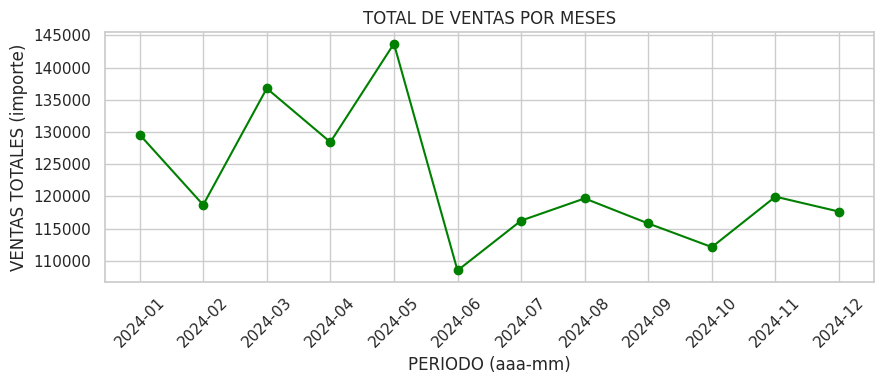

In [16]:

# CREO UN GRAFICO DE LINEAS PARA EXPLORAR VISUALMENTE LAS VENTAS MENSUALES:
plt.figure(figsize=(9, 4))

plt.plot(
    ventas_mes["anio_mes"],
    ventas_mes["ventas_totales"],
    marker="o",
    color="green"
)

plt.title("TOTAL DE VENTAS POR MESES")
plt.xlabel("PERIODO (aaa-mm)")
plt.ylabel("VENTAS TOTALES (importe)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:

# TOP TEN DE LOS PRODUCTOS MAS VENDIDOS:

N = 10
print("─"*150)
print("TOP TEN DE LOS PRODUCTOS MAS VENDIDOS")
print()
print("─"*150)
top_productos = prod_global.nlargest(N, 'ventas_total')
top_productos[['producto', 'ventas_total', 'unidades_vendidas', 'ticket_medio', 'ROAS']]


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
TOP TEN DE LOS PRODUCTOS MAS VENDIDOS

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


,producto,ventas_total,unidades_vendidas,ticket_medio,ROAS
0,Lámpara de mesa,82276.38,1112.0,73.99,5164.87
1,Auriculares,74175.58,958.0,77.43,4867.16
2,Microondas,72562.89,912.0,79.56,5113.66
3,Cafetera,59607.31,765.0,77.92,3282.34
4,Cuadro decorativo,54297.60,726.0,74.79,3425.72
5,Smartphone,54132.44,665.0,81.40,3426.10
6,Secadora,52115.45,696.0,74.88,3572.00
7,Jarrón decorativo,51130.88,672.0,76.09,3853.12
8,Batidora,50979.20,672.0,75.86,3336.34
9,Rincón de plantas,50456.45,691.0,73.02,3067.26


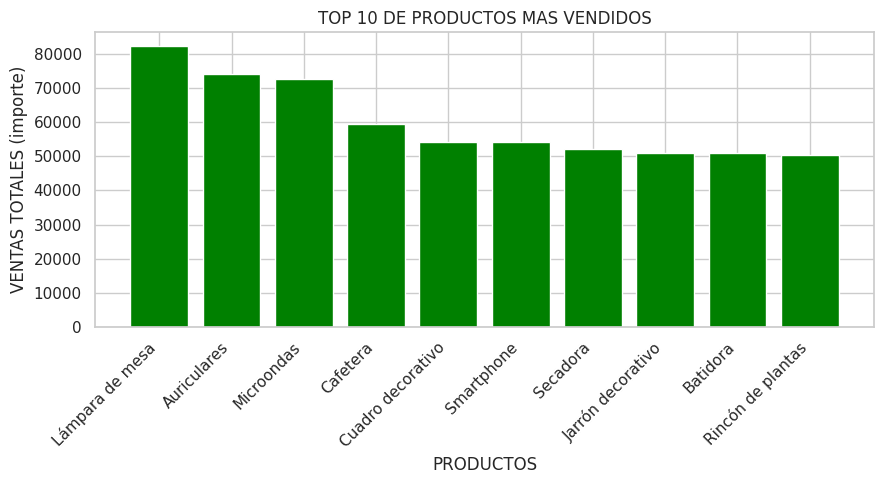

In [18]:
# CREO UN GRAFICO DE BARRAS PARA EXPLORAR VISUALMENTE EL TOP TEN DE VENTAS:

plt.figure(figsize=(9, 5))

plt.bar(
    top_productos["producto"],
    top_productos["ventas_total"],
    color="green")

plt.title(f"TOP {N} DE PRODUCTOS MAS VENDIDOS")
plt.xlabel("PRODUCTOS")
plt.ylabel("VENTAS TOTALES (importe)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
##### **COMENTARIOS SOBRE EL EDA:**

* 🛒 El mes con mayores ventas fué: MAYO por un total de: 143,727.25.
* 📉 El mes con menores ventas fué: JUNIO por un total de: 108,480.17
* 💰 El mayor importe de ventas registrado en ese mes fué de: 143,727.25
* 🛒 El artículo mas vendido fué: Lámpara de mesa.
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

3.3 CORRELACION:

- Evaluar la relación entre diferentes variables (por ejemplo, precio y cantidad vendida) y mostrar los resultados en un gráfico.

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
MATRIZ DE CORRELACION SOBRE "prod_global"



,ventas_total,unidades_vendidas,inversion_total,ticket_medio,ROAS
ventas_total,1.000000,0.990684,0.242179,0.464691,0.916866
unidades_vendidas,0.990684,1.000000,0.259788,0.347205,0.900989
inversion_total,0.242179,0.259788,1.000000,-0.029902,-0.156537
ticket_medio,0.464691,0.347205,-0.029902,1.000000,0.481477
ROAS,0.916866,0.900989,-0.156537,0.481477,1.000000



──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────



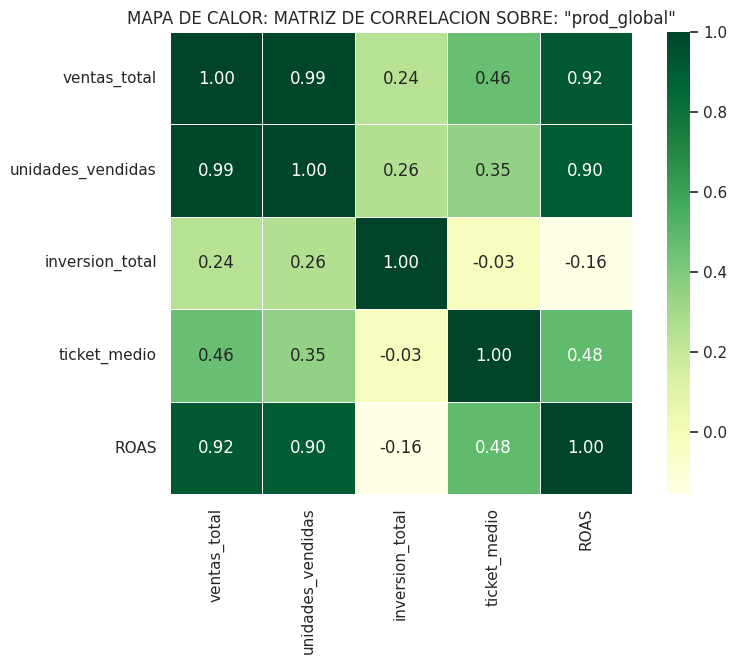

In [19]:
# CREO UNA MATRIZ DE CORRELACION SOBRE EL DATAFAME "prod_global":

columnas_corr = ["ventas_total",
                 "unidades_vendidas",
                 "inversion_total",
                 "ticket_medio",
                 "ROAS"
                 ]

# MUESTRO LA MATRIZ DE CORRELACION :
matriz_corr = prod_global[columnas_corr].corr()
print("─"*150)
print('MATRIZ DE CORRELACION SOBRE "prod_global"')
print()
display(matriz_corr)
print()
print("─"*150)
# CREO UN MAPA DE CALOR PARA EXPLORAR VISUALMENTE LA MATRIZ DE CORRELACION:

plt.figure(figsize=(9, 6))
sns.heatmap(
    matriz_corr,
    annot=True,        # muestra los valores
    fmt=".2f",         # formato de los números
    cmap="YlGn",       # paleta de colores
    linewidths=0.5,    # líneas divisorias
    square=True        # celdas cuadradas
)
print()
plt.title('MAPA DE CALOR: MATRIZ DE CORRELACION SOBRE: "prod_global"')
plt.show()

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
##### **COMENTARIOS SOBRE LA CORRELACION:**

👍
* 📈 Correlación Positiva:


1)  Se observa una "Correlación Positiva Perfecta"entre ventas_total vs. unidades_vendidas 0.99 a mayor unidades vendidas mayor ventas totales.

2) Se observa una "Correlación Positiva Fuerte" entre unidades_vendidas vs. ROAS 0.90 cuantas más unidades vendidas, mejor es el Retorno de la Inversión Publicitaria (ROAS).

3) Se observa una "Correlación Positiva Muy Fuerte" entre ventas_total vs. ROAS 0.92 las ventas totales y la métrica de eficiencia de la inversión están fuertemente ligadas.



👎
* 📉 Correlaciones Negativas y Cercanas a Cero:

1)  Se observa una "Correlación Negativa Débil" entre inversion_total vs. ROAS
-0.16 esto sugiere que a medida que aumenta la inversión total, el ROAS tiende a disminuir ligeramente. Invertir más no necesariamente resulta en una mejor eficiencia de la inversión.

2) Se observa una "Correlación Cercana a Cero" entre inversion_total vs. ticket_medio -0.03 esto indica que no hay una relación lineal significativa entre cuánto se invierte en marketing y el valor promedio del ticket de compra.


------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

3.4 CONSOLIDACION DE DATOS:

- Consolidar todos los análisis previos y preparar un conjunto de datos final que resuma los hallazgos clave para la presentación.

In [20]:
# CONSTRUYO EL DATAFRAME FINAL ("df_final") A PARTIR DEL DATAFRAME "prod_global":

df_final = prod_global[["producto",
                        "ventas_total",
                        "unidades_vendidas",
                        "inversion_total",
                        "campañas",
                        "ticket_medio",
                        "ROAS"]].copy()

# USANDO CUNTILES CREO UN SEGMENTO CUALITATIVO PARA LAS VENTAS (en 3 grupos):

df_final["segmento_ventas"] = pd.qcut(
            df_final["ventas_total"],
            q=3,
            labels=[
                "Bajo",
                "Medio",
                "Alto"
                ]
             )
# MUESTRO EL DATAFRAME RESULTANTE:

print("─"*150)
print('DATAFRAME RESULTANTE: "df_final"')
print()
print("─"*150)
display(df_final.head())
print("─"*150)
print()

# GUARDO EL DATAFRAME EN UN CSV COMO BACKUP LLAMADO "resumen_productos.csv":

df_final.to_csv("resumen_productos.csv", index=False)
print('Archivo "resumen_productos.csv" guardado correctamente.')

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
DATAFRAME RESULTANTE: "df_final"

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


,producto,ventas_total,unidades_vendidas,inversion_total,campañas,ticket_medio,ROAS,segmento_ventas
0,Lámpara de mesa,82276.38,1112.0,15.93,3,73.99,5164.87,Alto
1,Auriculares,74175.58,958.0,15.24,3,77.43,4867.16,Alto
2,Microondas,72562.89,912.0,14.19,3,79.56,5113.66,Alto
3,Cafetera,59607.31,765.0,18.16,3,77.92,3282.34,Alto
4,Cuadro decorativo,54297.60,726.0,15.85,3,74.79,3425.72,Alto


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Archivo "resumen_productos.csv" guardado correctamente.


# 👉***ENTREGA FINAL - ETAPA 4 - Visualización de Datos + Dashboard:***


>Objetivo: prender a visualizar datos de manera efectiva utilizando diversas bibliotecas.

1. Visualización con Matplotlib.
2. Visualización Avanzada con Seaborn.
3. Visualización Interactiva con Plotly.
4. Presentación Final.

4.1 Visualización con Matplotlib:

* Crear gráficos básicos (líneas, barras, dispersión) que representen las ventas con diferentes periodos de tiempo.

>>a) Grafico de linea de ventas mensuales.

>>b) Grafico de barras de productos con mayores ventas.

>>c) Grafico de dispersion de inversion en marketing vs ventas totales.

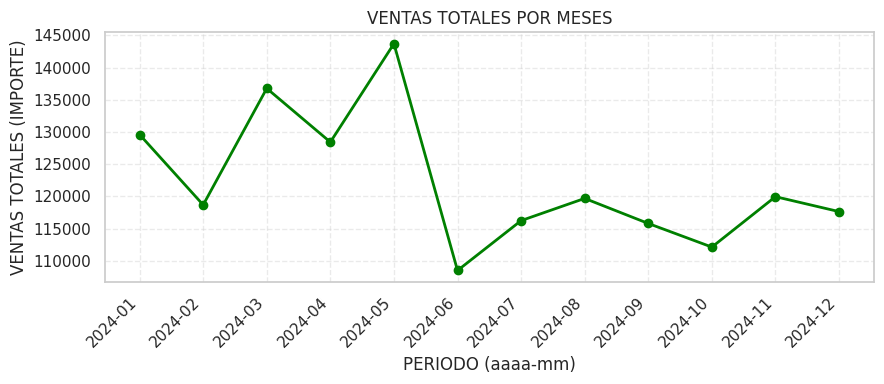

In [21]:

# CON MATPLOTLIB CREO UN GRAFICO DE LINEAS POR VENTAS MENSUALES:

plt.figure(figsize=(9, 4))

plt.plot(
    ventas_mes["anio_mes"],
    ventas_mes["ventas_totales"],
    color="green",
    marker="o",
    linestyle="-",
    linewidth=2
)

plt.title("VENTAS TOTALES POR MESES")
plt.xlabel("PERIODO (aaaa-mm)")
plt.ylabel("VENTAS TOTALES (IMPORTE)")
plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


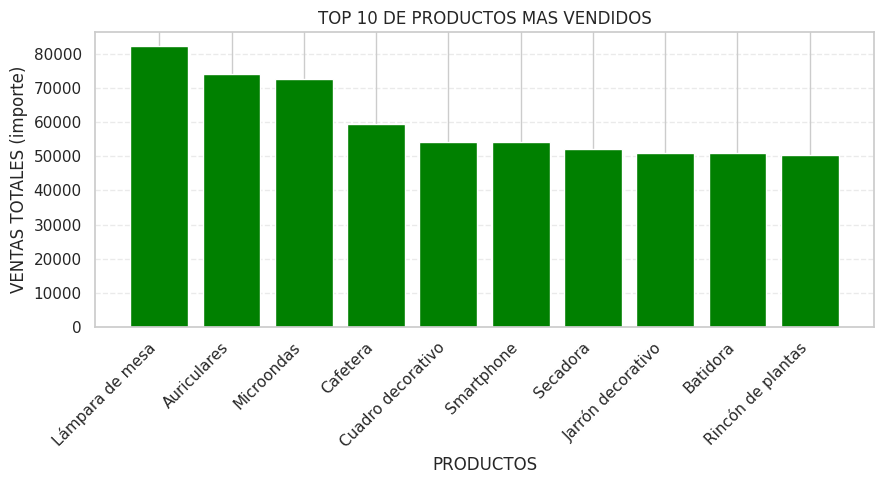

In [22]:
# CON MATPLOTLIB CREO UN GRAFICO DE BARRAS CON EL TOP TEN DE LOS PRODUCTOS MAS VENDIDOS:

plt.figure(figsize=(9, 5))

plt.bar(
    top_productos["producto"],
    top_productos["ventas_total"],
    color="green")

plt.title(f"TOP {N} DE PRODUCTOS MAS VENDIDOS")
plt.xlabel("PRODUCTOS")
plt.ylabel("VENTAS TOTALES (importe)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()

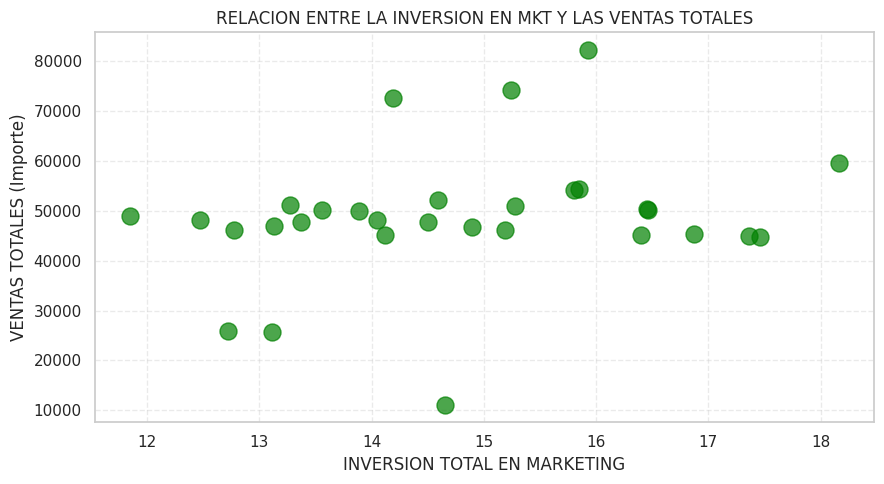

In [23]:
# CON MATPLOTLIB CREO UN GRAFICO DE DISPERSION PARA INVERSION VS VENTAS:

plt.figure(figsize=(9, 5))

plt.scatter(
    df_final["inversion_total"],
    df_final["ventas_total"],
    s=150,
    alpha=0.7,
    color="Green")


plt.title("RELACION ENTRE LA INVERSION EN MKT Y LAS VENTAS TOTALES")
plt.xlabel("INVERSION TOTAL EN MARKETING")
plt.ylabel("VENTAS TOTALES (Importe)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

4.2 Visualización Avanzada con Seaborn:

* Desarrollar visualizaciones estadísticas avanzadas, utilizando paletas y estilos para mejorar la presentación.

>>a) Histograma para la distribición de ROAS (ticket_medio).

>>b) Boxplot para Outliers en ventas_total.

>>c) Mapa de calor para matriz de correlación.

>>d) Scatterplot con codificacion de color por segmento.

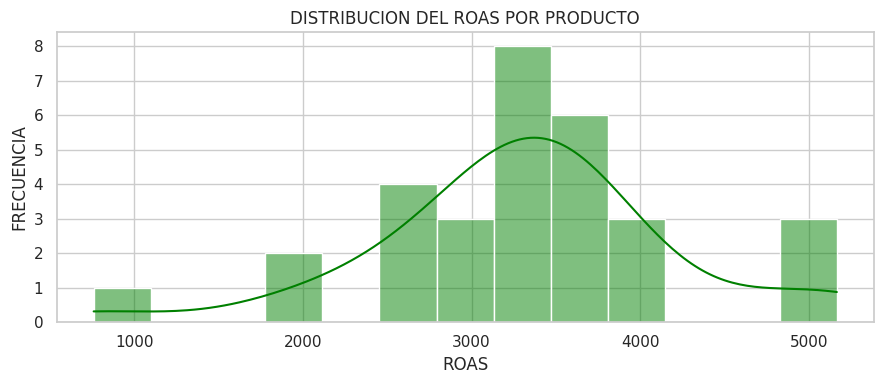

In [24]:
# HISTOGRAMA CON SEABORN + KDE DE ROAS

plt.figure(figsize=(9, 4))

sns.histplot(
    data=df_final,
    x="ROAS",
    color="green",
    kde=True
)

plt.title("DISTRIBUCION DEL ROAS POR PRODUCTO")
plt.xlabel("ROAS")
plt.ylabel("FRECUENCIA")
plt.tight_layout()
plt.show()

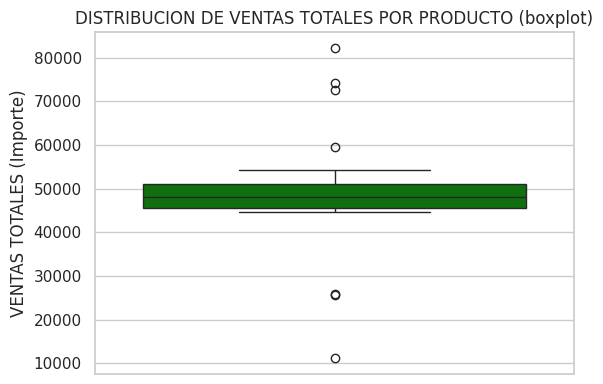

In [25]:
# BOXPLT CON SEABORN SOBRE VENTAS TOTALES (ventas_totales)

plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df_final,
    y='ventas_total',
   color="green"

)

plt.title("DISTRIBUCION DE VENTAS TOTALES POR PRODUCTO (boxplot)")
plt.ylabel("VENTAS TOTALES (Importe)")
plt.tight_layout()
plt.show()


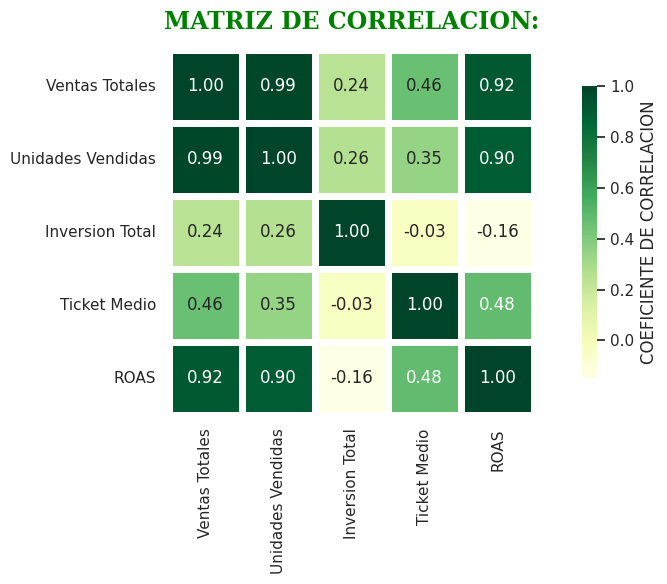

In [26]:
# MAPA DE CALOR CON SEABORN (Heatmap) PARA LA MATRIZ DE CORRELACION

plt.figure(figsize=(10, 6))

nombres_amigables = {
    "ventas_total": "Ventas Totales",
    "unidades_vendidas": "Unidades Vendidas",
    "inversion_total": "Inversion Total",
    "campañas": "Cantidad de Campañas",
    "ticket_medio": "Ticket Medio",
    "ROAS": "ROAS"
}

matriz_corr_renombrada = matriz_corr.rename(index=nombres_amigables,
                                            columns=nombres_amigables)

# Heatmap estético
sns.heatmap(
    matriz_corr_renombrada,
    annot=True,      # Mostramos valores en celdas
    fmt=".2f",       # Nro de decimales
    cmap="YlGn",     # paleta diferente
    vmin=-0.15,      # Extremos de la escala
    vmax=1,          #  (Cambiar y experimentar!)
    linewidths=3.7,     # Bordes entre celdas
    linecolor="white",  # Color de esas lineas
    cbar_kws={"shrink": 0.8, "label": "COEFICIENTE DE CORRELACION"},  # barra ajustada
    square=True      # Fuerza que las celdas sean cuadradas
)

# FUENTE PERSONALIZADA PARA EL TITULO
plt.title(
    "MATRIZ DE CORRELACION:",
    fontfamily="serif",
    fontsize=17,
    fontweight="bold",
    color="green",
    pad=15
)

plt.tight_layout()
plt.show()

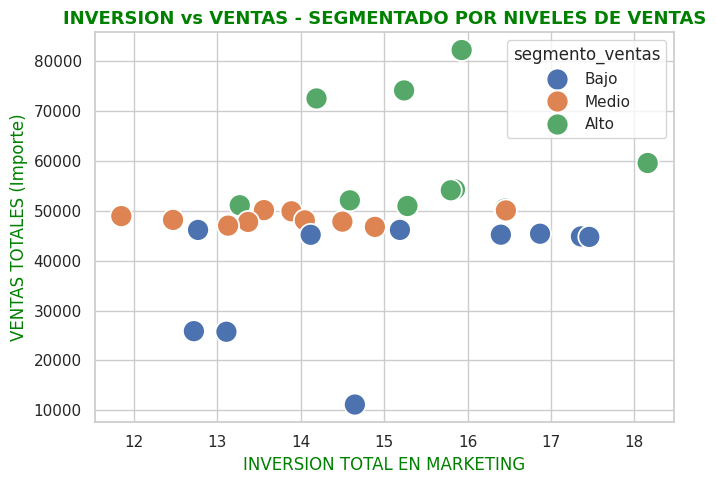

In [27]:
# GRAFICO DE DISPERSION -SCATTER- CON SEABORN PARA EL SEGMENTO DE VENTAS:

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df_final,
    x="inversion_total",
    y="ventas_total",
    hue="segmento_ventas",
    s=250
)

plt.title(
    "INVERSION vs VENTAS - SEGMENTADO POR NIVELES DE VENTAS",
    color="green",
    fontsize=13,
    fontweight="bold")

plt.xlabel("INVERSION TOTAL EN MARKETING", color="green")
plt.ylabel("VENTAS TOTALES (Importe)", color="green")
plt.tight_layout()
plt.show()


4.3 Visualización Interactiva con Plotly: **- DASHBOARD -**

* Construir un dashboard interactivo que combine múltiples visualizaciones, permitiendo al usuario explorar los datos dinámicamente.

>>a) Gráfico de barras: Ventas por producto (interactivo).

>>b) Gráfico de líneas: Ventas mensuales con tooltip.

>>c) Gráfico de dispersión: Inversion vs Ventas con informacion adicional al pasar el mouse sobre el dato.

In [28]:
# DASHBOARD INTERACTIVO:

# IMPORTO LIBRERIA Y MODULOS:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px

# DEFINO LA PALETA DE COLORES:
COLORES_VERDES = ['#4CAF50', '#81C784', '#A5D6A7', '#66BB6A']
COLOR_LINEA_VERDE = '#388E3C'

# CON SUBPLOTS DEFINO LA GRILLA O ESTRUCTURA DEL TABLERO Y SU DISTRIBUCION:
fig_dashboard = make_subplots(
    rows=2, cols=2,
    specs=[
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy", "colspan": 2}, None]
    ],
    subplot_titles=(
        "VENTAS TOTALES POR PRODUCTO 🛒",
        "EVOLUCION MENSUAL DE LAS VENTAS 💸",
        "RELACION ENTRE INVERSION EN MARKETING Y LAS VENTAS TOTALES 💰"
    )
)

# GRÁFICOS QUE COMPONEN EL DASHBOARD CON ESTILOS PERSONALIZADOS:

# a) GRAFICO DE BARRAS - VENTAS POR PRODUCTOS (VERDE):
fig_bar = px.bar(
    df_final.sort_values("ventas_total", ascending=False),
    x="producto",
    y="ventas_total",
    hover_data=["unidades_vendidas", "ticket_medio", "ROAS"],
    color_discrete_sequence=COLORES_VERDES
)
fig_bar.update_layout(xaxis_tickangle=-45, title_text="")

# b) GRAFICO DE LINEAS - VENTAS POR MESES (VERDE):
fig_line = px.line(
    ventas_mes,
    x="anio_mes",
    y="ventas_totales",
    title=" ",
    markers=True
)
fig_line.update_traces(line=dict(color=COLOR_LINEA_VERDE, width=3),
                       marker=dict(color=COLOR_LINEA_VERDE, size=8))
fig_line.update_layout(xaxis_tickangle=-45, title_text="")

# c) GRAFICO DE DISPERSION - INVERSION VS VENTAS (BURBUJAS MÁS GRANDES):
fig_scatter = px.scatter(
    df_final,
    x="inversion_total",
    y="ventas_total",
    color="segmento_ventas",
    hover_data=["producto", "ROAS", "ticket_medio"],
    title=" "
)
# CAMBIO PROPIEDADES Y TAMAÑO DE LAS BURBUJAS:
fig_scatter.update_traces(marker=dict(size=15, opacity=0.8, line=dict(width=0.5, color='DarkSlateGrey')))

# AGREGO LOS GRÁFICOS EN LAS GRILLAS DEL DASHBOARD CORRESPONDIENTES:

# GRAFICO DE BARRAS (FILA 1 - COLUMNA 1):
for trace in fig_bar.data:
    fig_dashboard.add_trace(trace, row=1, col=1)

# GRAFICO DE LINEAS (FILA 1 - COLUMNA 2):
for trace in fig_line.data:
    fig_dashboard.add_trace(trace, row=1, col=2)

# GRAFICO DE DISPERSION (FILA 2 - COLUMNAS 1 Y 2):
for trace in fig_scatter.data:
    fig_dashboard.add_trace(trace, row=2, col=1)

# AJUSTE DE EJES Y LAYOUT GENERAL:
fig_dashboard.update_xaxes(tickangle=-45, row=1, col=1)
fig_dashboard.update_xaxes(tickangle=-45, row=1, col=2)

fig_dashboard.update_layout(
    height=800,
    width=1000,
    title_text="📊 *DASHBOARD INTERACTIVO: VENTAS Y MARKETING* (Plotly)",
    title_font_size=24,
    showlegend=True,
    legend_title_text="Segmento de Ventas",
    margin=dict(l=50, r=50, t=100, b=50),
    hovermode="x unified",
    template="plotly_white",
    title_font=dict(
        family="Courier New, monospace",
        size=28,
        color="#388E3C",
        weight="bold"
        )
)

# CAMBIO PROPIEDADES Y TAMAÑO DE LOS SUBTÍTULOS DE LOS SUBPLOTS:
fig_dashboard.update_annotations(
    font_color="#388E3C", # Color de subtitulos
    font_size=16, # Tamaño de la letra
    font_family="Arial, sans-serif", # Fuente
    #font_weight="bold",
    font_style="italic"
)

# MUESTRO EL DASHBOARD:
fig_dashboard.show()




Alumno: G.L.

Comisión: 25261

Profesor: Ariel Palazzesi